# LSTM MODEL

In [ ]:
import pickle
import numpy as np

with open('data/processed_data.pkl', 'rb') as f:
    payload = pickle.load(f)

if isinstance(payload, dict):
    X_train = payload['X_train']
    X_test = payload['X_test']
    y_train = payload['y_train']
    y_test = payload['y_test']
    target_scaler = payload['target_scaler']
    feature_cols = payload.get('feature_cols', [])
else:
    # Backward compatibility with old tuple format
    X_train, X_test, y_train, y_test, scaler = payload
    target_scaler = scaler
    feature_cols = ['Close']

# Keep this alias for compatibility with downstream cells
scaler = target_scaler

print('X_train shape:', X_train.shape)
print('X_test shape:', X_test.shape)
print('Features:', feature_cols)

X_train shape: (1133, 60, 1)
X_test shape: (284, 60, 1)


In [ ]:
# LSTM model building (stabilized for less overfitting)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

np.random.seed(42)
tf.random.set_seed(42)

model = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(48, return_sequences=True),
    Dropout(0.3),

    LSTM(24, return_sequences=False),
    Dropout(0.3),

    Dense(16, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dense(1)
])

optimizer = Adam(learning_rate=5e-4, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='huber')
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                   │ (None, 60, 48)         │         9,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 60, 48)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 24)             │         7,008 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 24)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,025 (66.50 KB)

 Trainable params: 17,025 (66.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Callbacks for stable validation behavior
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    ModelCheckpoint("models/lstm_model.h5", monitor="val_loss", save_best_only=True),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=8,
        min_lr=1e-6,
        verbose=1
    )
]

In [18]:
# Train the model with chronological validation split
val_size = int(len(X_train) * 0.15)
X_tr, X_val = X_train[:-val_size], X_train[-val_size:]
y_tr, y_val = y_train[:-val_size], y_train[-val_size:]

history = model.fit(
    X_tr, y_tr,
    epochs=100,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    shuffle=False,
    verbose=1
)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0296

16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0406 - val_loss: 0.0464 - learning_rate: 5.0000e-04
Epoch 2/100
15/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0045

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0072 - val_loss: 0.0034 - learning_rate: 5.0000e-04
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0116 - val_loss: 0.0103 - learning_rate: 5.0000e-04
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0065 - val_loss: 0.0049 - learning_rate: 5.0000e-04
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0054 - val_loss: 0.0042 - learning_rate: 5.0000e-04
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0036

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.0047 - val_loss: 0.0030 - learning_rate: 5.0000e-04
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0044 - val_loss: 0.0040 - learning_rate: 5.0000e-04
Epoch 8/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 0.0036

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0057 - val_loss: 0.0029 - learning_rate: 5.0000e-04
Epoch 9/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0048 - val_loss: 0.0035 - learning_rate: 5.0000e-04
Epoch 10/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 0.0031

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0044 - val_loss: 0.0027 - learning_rate: 5.0000e-04
Epoch 11/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.0042 - val_loss: 0.0040 - learning_rate: 5.0000e-04
Epoch 12/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0048 - val_loss: 0.0032 - learning_rate: 5.0000e-04
Epoch 13/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0040 - val_loss: 0.0032 - learning_rate: 5.0000e-04
Epoch 14/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0038 - val_loss: 0.0030 - learning_rate: 5.0000e-04
Epoch 15/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0036 - val_loss: 0.0040 - learning_rate: 5.0000e-04
Epoch 16/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0050 - val_loss: 0.0038 - learning_rate: 5.0000e-04
Epoch 17/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0043 - val_loss: 0.0041 - learning_rate: 5.0000e-04
Epoch 18/100
14/16 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0024
Epoch 18: ReduceLROnPlate

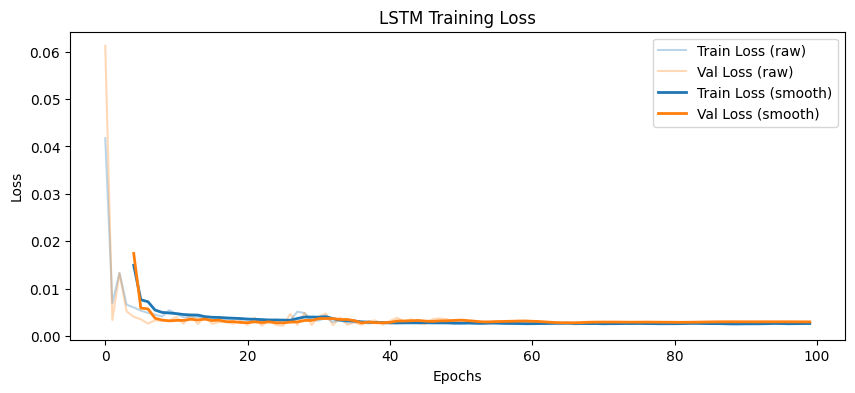

In [5]:
# Plot training history (raw + smoothed)
import matplotlib.pyplot as plt

train_loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(10, 4))
plt.plot(train_loss, label='Train Loss (raw)', color='tab:blue', alpha=0.3)
plt.plot(val_loss, label='Val Loss (raw)', color='tab:orange', alpha=0.3)

window = 5
if len(train_loss) >= window:
    train_smooth = np.convolve(train_loss, np.ones(window)/window, mode='valid')
    val_smooth = np.convolve(val_loss, np.ones(window)/window, mode='valid')
    x = np.arange(window - 1, len(train_loss))
    plt.plot(x, train_smooth, label='Train Loss (smooth)', color='tab:blue', linewidth=2)
    plt.plot(x, val_smooth, label='Val Loss (smooth)', color='tab:orange', linewidth=2)

plt.title('LSTM Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
# Evaluate the best saved model
from tensorflow.keras.models import load_model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

best_model = load_model('models/lstm_model.h5', compile=False)
y_pred_scaled = best_model.predict(X_test, verbose=0)

# Inverse transform back to price values
y_pred = target_scaler.inverse_transform(y_pred_scaled).reshape(-1)
y_actual = target_scaler.inverse_transform(y_test.reshape(-1, 1)).reshape(-1)

rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
mae = mean_absolute_error(y_actual, y_pred)
mape = np.mean(np.abs((y_actual - y_pred) / np.clip(np.abs(y_actual), 1e-8, None))) * 100

print(f'RMSE : {rmse:.2f}')
print(f'MAE  : {mae:.2f}')
print(f'MAPE : {mape:.2f}%')

📊 RMSE : ₹890.98
📊 MAE  : ₹761.96
📊 MAPE : 3.95%


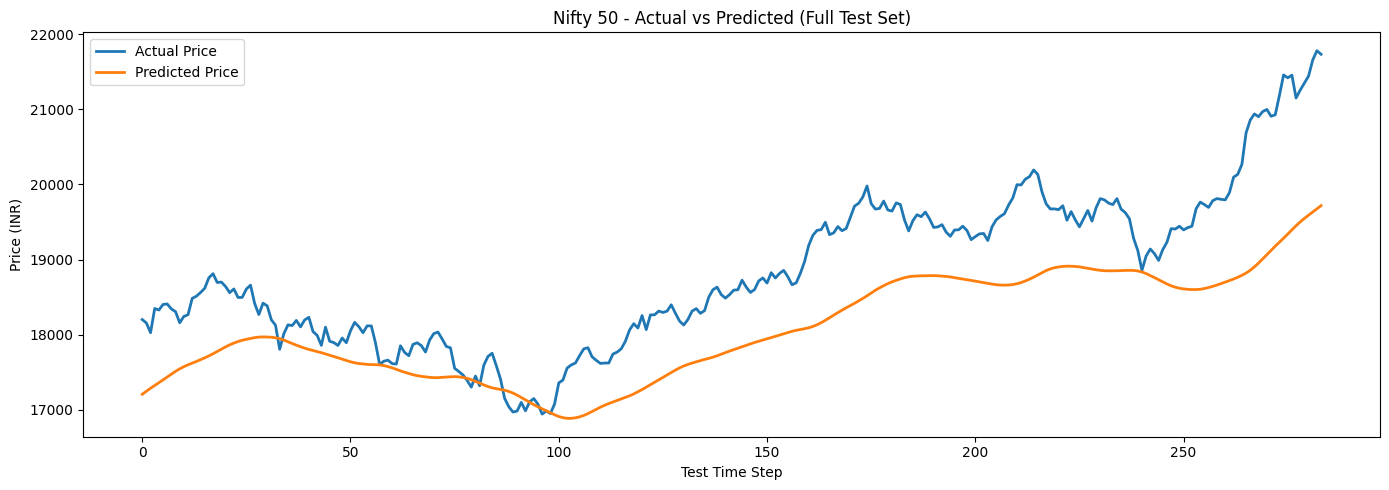

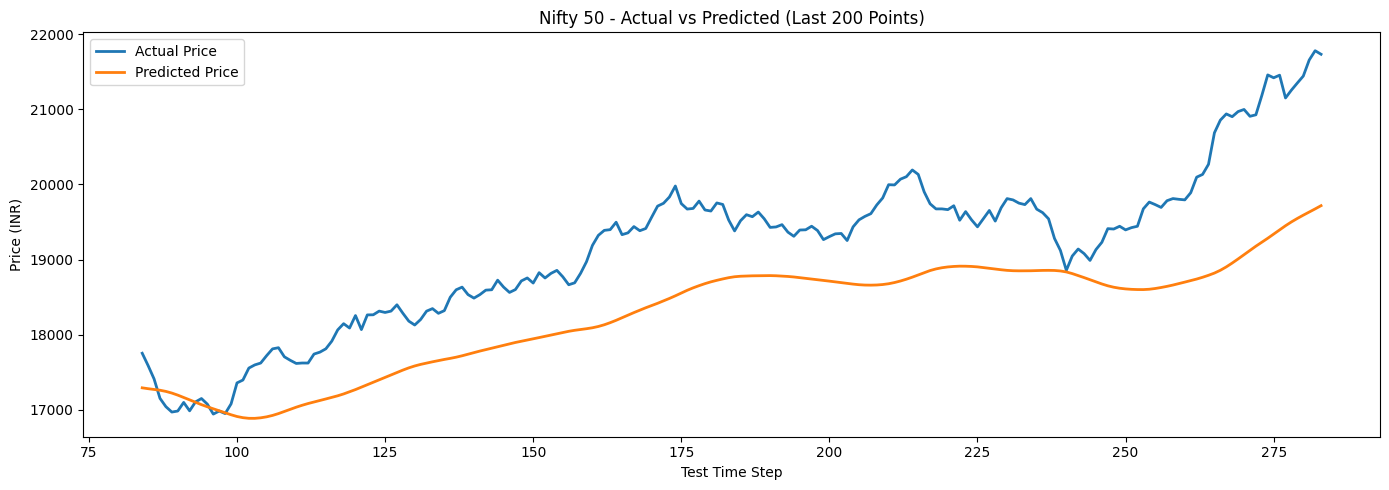

In [20]:
# Plot predicted vs actual (recent window + full test trend)
import matplotlib.pyplot as plt

n = len(y_actual)
x = np.arange(n)

plt.figure(figsize=(14, 5))
plt.plot(x, y_actual, label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x, y_pred, label='Predicted Price', color='tab:orange', linewidth=2)
plt.title('Nifty 50 - Actual vs Predicted (Full Test Set)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()

# Optional zoom: last 200 points for easier visual comparison
zoom = min(200, n)
plt.figure(figsize=(14, 5))
plt.plot(x[-zoom:], y_actual[-zoom:], label='Actual Price', color='tab:blue', linewidth=2)
plt.plot(x[-zoom:], y_pred[-zoom:], label='Predicted Price', color='tab:orange', linewidth=2)
plt.title(f'Nifty 50 - Actual vs Predicted (Last {zoom} Points)')
plt.xlabel('Test Time Step')
plt.ylabel('Price (INR)')
plt.legend()
plt.tight_layout()
plt.show()